# Modélisation de données avec gradient boosting

Dans ce notebook, nous explorons l’utilisation de modèles de gradient boosting, à savoir **LightGBM** et **XGBoost**, afin de modéliser le trafic cycliste horaire à Paris.

Ces modèles sont particulièrement adaptés aux données tabulaires structurées et permettent de capturer des relations non linéaires complexes entre les variables explicatives.

Comme pour les modèles précédents, les performances sont mesurées avec la **MAE**, la **RMSE** et le **R²**.

## Import des librairies et des données

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path

from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

/Users/binn/ds/portfolio/velo-paris/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../data/processed/df_processed.csv', sep=',')

In [3]:
df.head()

,Nom du compteur,Nom du site de comptage,Comptage horaire,Date et heure de comptage,Lien vers photo du site de comptage,Direction,Latitude,Longitude,Température (°C),Précipitations (mm),...,Mois,Année,Heure,Jour de la semaine,Week-end,Vacances,lag_1h,lag_24h,lag_168h,roll_mean_3h
0,10 avenue de la Grande Armée 10 avenue de la G...,10 avenue de la Grande Armée,0,2025-01-07 11:00:00,https://filer.eco-counter-tools.com/file/26/1d...,Bike IN,48.8748,2.2924,4.3,1.8,...,1,2025,11,1,0,0,NaN,NaN,NaN,NaN
1,10 avenue de la Grande Armée 10 avenue de la G...,10 avenue de la Grande Armée,13,2025-01-07 12:00:00,https://filer.eco-counter-tools.com/file/26/1d...,Bike IN,48.8748,2.2924,5.4,0.0,...,1,2025,12,1,0,0,0.0,NaN,NaN,NaN
2,10 avenue de la Grande Armée 10 avenue de la G...,10 avenue de la Grande Armée,50,2025-01-07 13:00:00,https://filer.eco-counter-tools.com/file/26/1d...,Bike IN,48.8748,2.2924,6.3,0.0,...,1,2025,13,1,0,0,13.0,NaN,NaN,NaN
3,10 avenue de la Grande Armée 10 avenue de la G...,10 avenue de la Grande Armée,54,2025-01-07 14:00:00,https://filer.eco-counter-tools.com/file/26/1d...,Bike IN,48.8748,2.2924,6.8,0.5,...,1,2025,14,1,0,0,50.0,NaN,NaN,21.0
4,10 avenue de la Grande Armée 10 avenue de la G...,10 avenue de la Grande Armée,33,2025-01-07 15:00:00,https://filer.eco-counter-tools.com/file/26/1d...,Bike IN,48.8748,2.2924,6.9,0.0,...,1,2025,15,1,0,0,54.0,NaN,NaN,39.0


## Préparation des données avant entraînement

In [4]:
df.columns

Index(['Nom du compteur', 'Nom du site de comptage', 'Comptage horaire',
       'Date et heure de comptage', 'Lien vers photo du site de comptage',
       'Direction', 'Latitude', 'Longitude', 'Température (°C)',
       'Précipitations (mm)', 'Jour du mois', 'Mois', 'Année', 'Heure',
       'Jour de la semaine', 'Week-end', 'Vacances', 'lag_1h', 'lag_24h',
       'lag_168h', 'roll_mean_3h'],
      dtype='object')

In [5]:
feature_cols_num = ['Année', 'Mois', 'Jour du mois', 'Heure', 'Jour de la semaine', 'Week-end', 'Vacances', 'lag_1h', 'lag_24h',
                    'lag_168h', 'roll_mean_3h', 'Température (°C)', 'Précipitations (mm)']

feature_cols_cat = ['Nom du compteur', 'Direction']

for col in feature_cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Assure que toutes les colonnes numériques sont bien en format numérique

df_clean = df.dropna(subset=feature_cols_num +
                     feature_cols_cat + ['Comptage horaire']).copy()
# Supprime les valeurs vides (en particulier celles des colonnes lag)

df['Date et heure de comptage'] = pd.to_datetime(
    df['Date et heure de comptage'], errors='coerce')
# Convertit 'Date et heure de comptage' en format datetime

df_clean = df_clean.sort_values('Date et heure de comptage')

split = int(len(df_clean) * 0.8)
train = df_clean.iloc[:split]
test = df_clean.iloc[split:]
# Sépare le dataset chronologiquement

X_train = train[feature_cols_num + feature_cols_cat]
y_train = train['Comptage horaire']
X_test = test[feature_cols_num + feature_cols_cat]
y_test = test['Comptage horaire']

preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', feature_cols_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_cat)
    ],
    remainder='drop'
)

## Entraînement de modèle (1) : LightGBM

In [6]:
model_lgbm = Pipeline(steps=[
    ('prep', preprocess),
    ('model', LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1))
])

model_lgbm.fit(X_train, y_train)
pred_lgbm_test = model_lgbm.predict(X_test)

mae_lgbm = mean_absolute_error(y_test, pred_lgbm_test)
rmse_lgbm = root_mean_squared_error(y_test, pred_lgbm_test)
r2_lgbm_test = r2_score(y_test, pred_lgbm_test)

pred_lgbm_train = model_lgbm.predict(X_train)
r2_lgbm_train = r2_score(y_train, pred_lgbm_train)

print(
    f"LightGBM — MAE = {mae_lgbm:.2f}, RMSE = {rmse_lgbm:.2f}, R²-test = {r2_lgbm_test:.3f}, R²-train = {r2_lgbm_train:.3f}")

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

joblib.dump(model_lgbm, models_dir/'model_lgbm.joblib')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006604 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1652
[LightGBM] [Info] Number of data points in the train set: 743327, number of used features: 129
[LightGBM] [Info] Start training from score 77.165354


/Users/binn/ds/portfolio/velo-paris/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/binn/ds/portfolio/velo-paris/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM — MAE = 13.61, RMSE = 23.89, R²-test = 0.958, R²-train = 0.969


['../models/model_lgbm.joblib']

Les hyperparamètres de LightGBM ont été choisis afin de définir un modèle de base robuste, sans recourir à une optimisation exhaustive.

Un nombre relativement élevé d’arbres (n_estimators = 500) combiné à un faible taux d’apprentissage (learning_rate = 0.05) permet au modèle d’apprendre progressivement les structures complexes tout en limitant le risque de sur-apprentissage.

Les paramètres subsample et colsample_bytree, fixés à 0.8, introduisent une forme de régularisation en ajoutant de l’aléa dans la construction des arbres. Le nombre de feuilles (num_leaves = 31) correspond à la valeur par défaut de LightGBM et permet de contrôler la complexité de chaque arbre.

Ce jeu de paramètres constitue ainsi un compromis classique entre performance, stabilité et temps de calcul.

## Entraînement de modèle (2) : XGBoost

In [7]:
model_xgb = Pipeline(steps=[
    ('prep', preprocess),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective='reg:squarederror',
        tree_method='hist',
        random_state=42,
        n_jobs=-1))
])

model_xgb.fit(X_train, y_train)
pred_xgb_test = model_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb_test)
rmse_xgb = root_mean_squared_error(y_test, pred_xgb_test)
r2_xgb_test = r2_score(y_test, pred_xgb_test)

pred_xgb_train = model_xgb.predict(X_train)
r2_xgb_train = r2_score(y_train, pred_xgb_train)

print(
    f"XGBoost — MAE = {mae_xgb:.2f}, RMSE = {rmse_xgb:.2f}, R²-test = {r2_xgb_test:.3f}, R²-train = {r2_xgb_train:.3f}")

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

joblib.dump(model_xgb, models_dir/'model_xgb.joblib')

XGBoost — MAE = 13.52, RMSE = 24.09, R²-test = 0.957, R²-train = 0.969


['../models/model_xgb.joblib']

Pour XGBoost, les hyperparamètres ont été fixés afin d’obtenir un modèle de base robuste, comparable à LightGBM, sans optimiser exhaustivement.

Le couple learning_rate = 0.05 et n_estimators = 500 permet un apprentissage progressif et stable, limitant le risque de sur-apprentissage. La complexité des arbres est contrôlée via max_depth = 6, tandis que subsample = 0.8 et colsample_bytree = 0.8 apportent une régularisation supplémentaire en introduisant de l’aléa dans la construction des arbres.

La régularisation L2 (reg_lambda = 1.0, valeur par défaut) contribue également à stabiliser l’apprentissage. Enfin, tree_method = 'hist' est utilisé pour accélérer l’entraînement sur CPU, sans dégrader significativement la performance.

## Bilan

Observations sur le dataset de mai 2024 à juin 2025 :

Les deux modèles atteignent des résultats très proches, avec une **MAE de 13.52-13.61, une RMSE de 23.89-24.09 et un R² proche de 0.96**.

Comparés aux modèles précédemment testés, les gains sont significatifs : les modèles linéaires plafonnaient autour de 0.895 de R², tandis que le Random Forest atteignait 0.932. Les modèles de gradient boosting parviennent à mieux capturer les interactions non linéaires et les dynamiques temporelles complexes du trafic cycliste.

Les performances très similaires de LightGBM et XGBoost indiquent que les deux approches sont bien adaptées à ce problème. **LightGBM est toutefois privilégié** en raison de son efficacité computationnelle, tout en conservant une qualité de prédiction équivalente.

## Interprétabilité du modèle avec SHAP

Afin de mieux comprendre le comportement du meilleur modèle (LightGBM), nous utilisons les valeurs SHAP pour analyser l’influence des variables, à la fois globalement et pour des prédictions individuelles.

In [8]:
lgbm = model_lgbm.named_steps['model']
preprocess = model_lgbm.named_steps['prep']
# On récupère le modèle final entraîné (lgbm) ainsi que le pipeline de pré-traitement (preprocess).

X_train_transformed = preprocess.transform(X_train)
# On applique le même pré-traitement afin d'obtenir l'espace de features réellement utilisé par le modèle.

feature_names = preprocess.get_feature_names_out()
# On récupère les noms de variables après le pré-traitement (incluant les variables créées par OneHotEncoding).

# Afin de réduire le temps de calcul des valeurs SHAP, on travaille sur un sous-échantillon aléatoire des données :
n = 10000
idx = np.random.choice(
    # nombre total de lignes dans le dataset transformé
    X_train_transformed.shape[0],
    # On choisit jusqu'à n éléments. Si le dataset en contient moins, on récupère toutes les lignes.
    min(n, X_train_transformed.shape[0]),
    replace=False  # Une même ligne ne peut pas être sélectionnée deux fois.
)
# On extrait le sous-échantillon à partir des indices tirés aléatoirement.
X_sample = X_train_transformed[idx]

# On calcule les valeurs SHAP pour chaque observation dans X_sample :
booster = lgbm.booster_  # Donne accès au modèle LightGBM natif ("booster")
contrib = booster.predict(X_sample, pred_contrib=True)
# pred_contrib retourne pour chaque observation :
# - une contribution SHAP par variable
# - une valeur supplémentaire correspondant à la valeur de base (expected value).

# prédiction = valeur de base + contributions SHAP

contrib_dense = contrib.toarray()
# On assure que contrib est en format numpy array, essentiel pour l'analyse et la visualisation.

shap_values = contrib_dense[:, :-1]
expected_value = contrib_dense[:, -1]

X_plot = X_sample.toarray()
# On convertit également X_sample en numpy array pour la visualisation.

In [9]:
clean_feature_names = [
    name
    .replace('num__', '')
    .replace('cat__', '')
    .replace('_', ' ')
    for name in feature_names
]

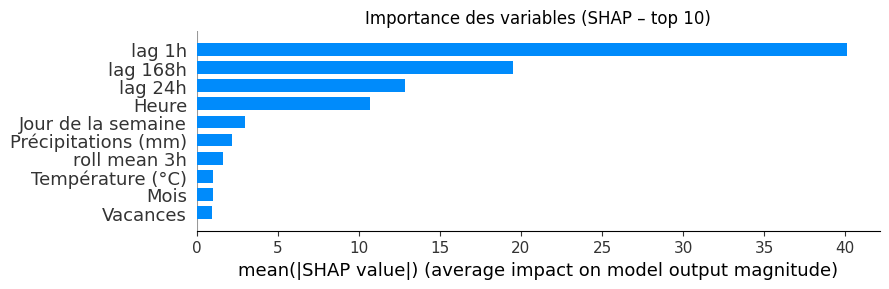

In [10]:
shap.summary_plot(
    shap_values,
    X_plot,
    feature_names=clean_feature_names,
    plot_type='bar',
    max_display=10,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(9, 3)
plt.title("Importance des variables (SHAP – top 10)")
plt.tight_layout()
plt.savefig('../reports/figures/shap_top_10_variables.png', dpi=150)
plt.show()

Ce graphique SHAP met en évidence les variables ayant l’impact moyen le plus important sur les prédictions du modèle LightGBM.

Les résultats montrent que la dynamique temporelle du trafic cycliste constitue le principal moteur des prédictions : le comptage observé une heure auparavant (lag 1h) est de loin la variable la plus influente, suivi des valeurs observées une semaine (lag 168h) et une journée (lag 24h) plus tôt. Cela confirme la forte présence de cycles journaliers et hebdomadaires.

L’heure de la journée joue également un rôle significatif, traduisant des pics d’usage récurrents au cours de la journée.

En revanche, les variables calendaires (jour de la semaine, mois, vacances) et les conditions météorologiques (précipitations et température) présentent un impact moyen plus limité.

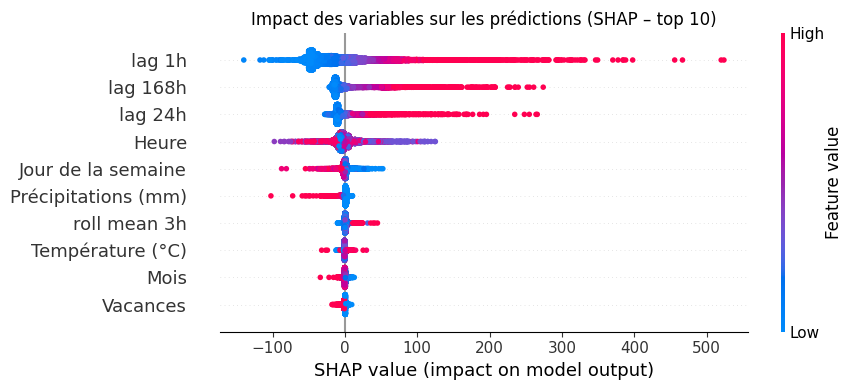

In [11]:
shap.summary_plot(
    shap_values,
    X_plot,
    feature_names=clean_feature_names,
    max_display=10,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(9, 4)
plt.title("Impact des variables sur les prédictions (SHAP – top 10)")
plt.tight_layout()
plt.savefig('../reports/figures/shap_impact_variables_top_10.png', dpi=150)
plt.show()

Ce graphique SHAP permet d’analyser à la fois l’importance des variables et le sens de leur influence sur les prédictions du modèle LightGBM.

Pour lag 1h, lag 168h et lag 24h, les valeurs élevées (en rouge) sont majoritairement associées à des contributions SHAP positives, indiquant une augmentation des prédictions lorsque les comptages passés sont élevés, tandis que les valeurs faibles (en bleu) ont l’effet inverse. Cela confirme la forte dépendance temporelle du trafic cycliste et la présence de cycles journaliers et hebdomadaires marqués.

La variable Heure présente une dispersion plus symétrique, traduisant des effets contrastés selon les moments de la journée, en lien avec les pics et creux de fréquentation.

Les variables météorologiques et calendaires montrent des contributions globalement plus faibles et concentrées autour de zéro, suggérant qu’elles jouent un rôle secondaire dans les prédictions.

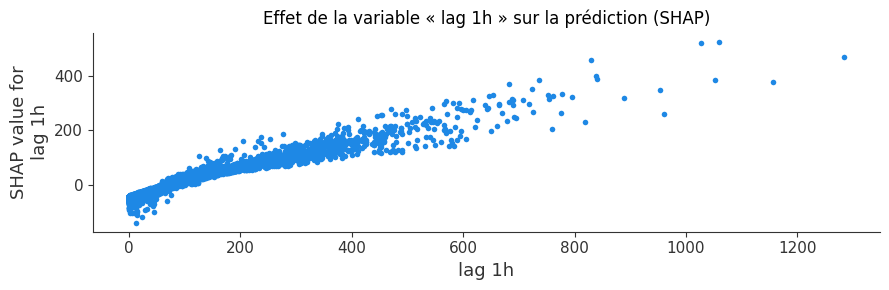

In [12]:
shap.dependence_plot(
    'lag 1h',
    shap_values,
    X_plot,
    feature_names=clean_feature_names,
    interaction_index=None,
    show=False
)

plt.gcf().set_size_inches(9, 3)
plt.title("Effet de la variable « lag 1h » sur la prédiction (SHAP)")
plt.tight_layout()
plt.savefig('../reports/figures/shap_dependence_lag_1h.png', dpi=150)
plt.show()

Le graphique de dépendance SHAP pour la variable lag 1h met en évidence une relation positive forte et non linéaire entre le trafic observé une heure auparavant et la prédiction du modèle.

Lorsque le comptage à t−1h est faible, la contribution SHAP est négative ou proche de zéro, ce qui conduit le modèle à diminuer sa prédiction. À mesure que le trafic récent augmente, la contribution SHAP croît rapidement, traduisant une augmentation significative de la prédiction.

Cette relation tend toutefois à se stabiliser pour les valeurs élevées du lag 1h, suggérant un effet de saturation : au-delà d’un certain niveau de trafic, une augmentation supplémentaire a un impact marginalement plus faible sur la prédiction.

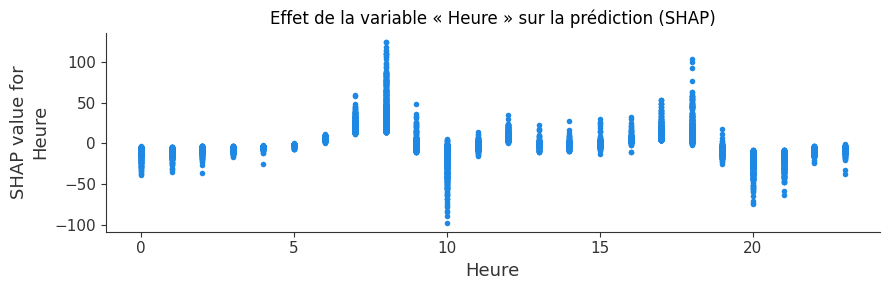

In [13]:
shap.dependence_plot(
    'Heure',
    shap_values,
    X_plot,
    feature_names=clean_feature_names,
    interaction_index=None,
    show=False
)

plt.gcf().set_size_inches(9, 3)
plt.title("Effet de la variable « Heure » sur la prédiction (SHAP)")
plt.tight_layout()
plt.savefig('../reports/figures/shap_dependence_heure.png', dpi=150)
plt.show()

Le graphique de dépendance SHAP associé à la variable Heure révèle une structure fortement non linéaire, reflétant les variations quotidiennes du trafic cycliste.

Certaines heures de la journée présentent des contributions SHAP positives marquées, correspondant aux périodes de forte fréquentation, notamment le matin et en fin de journée, tandis que d’autres heures, en particulier autour de la mi-journée et en soirée tardive, sont associées à des contributions négatives. Cette alternance d’effets positifs et négatifs traduit l’existence de cycles journaliers bien définis.

La dispersion observée pour une même heure indique également que l’effet de l’heure dépend du contexte (trafic récent, jour, conditions externes...), soulignant l’interaction entre les variables temporelles.